In [32]:
### 导入数据
import torch
from torchvision import datasets
from torchvision.transforms import ToTensor
train_dataset = datasets.FashionMNIST(root = './data', download= True, transform= ToTensor(), train= True)
test_dataset = datasets.FashionMNIST(root='./data',download= True, transform= ToTensor(), train=False)
print(train_dataset[0][0].shape)
print(test_dataset[0][0].shape)


torch.Size([1, 28, 28])
torch.Size([1, 28, 28])


In [33]:
from torch.utils.data import DataLoader
from tqdm import tqdm
import torch.nn as nn
train_loader = DataLoader(train_dataset,batch_size=256,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size = 256,shuffle=False)
for x, y in tqdm(train_loader):
    print(x.shape,y.shape)
    x_1 = x
    break
print(x_1.shape)
print(nn.Flatten()(x_1).shape)
print(x_1.view(-1,28*28).shape)


  0%|          | 0/235 [00:00<?, ?it/s]

torch.Size([256, 1, 28, 28]) torch.Size([256])
torch.Size([256, 1, 28, 28])
torch.Size([256, 784])
torch.Size([256, 784])


In [34]:
### 建立模型
import torch.nn as nn
class Classic(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.nets = nn.Sequential(
            nn.Linear(input_dim,output_dim),
            nn.ReLU()
        )
    def forward(self,x):
        return self.nets(x)

class MyModel(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim, layers ):
        super().__init__()
        self.layers = nn.Sequential(
            Classic(input_dim,hidden_dim),
            *[Classic(hidden_dim,hidden_dim) for _ in range(layers)],
            nn.Linear(hidden_dim, output_dim)
        )
    def forward(self,x):
        x = nn.Flatten()(x)
        return self.layers(x)
    
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = MyModel(28*28,10,256,2).to(device)
print(model)
# for i in model.parameters():
#     print(i.shap

MyModel(
  (layers): Sequential(
    (0): Classic(
      (nets): Sequential(
        (0): Linear(in_features=784, out_features=256, bias=True)
        (1): ReLU()
      )
    )
    (1): Classic(
      (nets): Sequential(
        (0): Linear(in_features=256, out_features=256, bias=True)
        (1): ReLU()
      )
    )
    (2): Classic(
      (nets): Sequential(
        (0): Linear(in_features=256, out_features=256, bias=True)
        (1): ReLU()
      )
    )
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [35]:
criterion = nn.CrossEntropyLoss() ### softmax + crossentropy
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

In [38]:
### training process
import os
import matplotlib.pyplot as plt
from IPython.display import clear_output
def trainer():
    if not os.path.isdir('./models'):
        os.mkdir('./models')
    train_losses = []
    train_accs = []
    test_losses = []
    test_accs = []
    count = 0
    early_count = 20
    best_acc = 0
    num_epochs = 50
    for epoch in range(num_epochs):
        train_acc = 0
        train_loss = 0
        model.train()
        for _, batch in enumerate(tqdm(train_loader)):
            optimizer.zero_grad()
            features, labels = batch
            features, labels = features.to(device), labels.to(device)
            pred = model(features)
            _, train_pred = torch.max(pred, dim = 1)
            loss = criterion(pred, labels)
            train_loss += loss.detach().cpu().item()
            train_acc += (train_pred.detach() == labels).float().mean().item()
            loss.backward()
            optimizer.step()

        train_losses.append(train_loss / len(train_loader))
        train_accs.append(train_acc / len(train_loader))

        test_loss = 0
        test_acc = 0
        if len(test_loader.dataset) > 0:
            model.eval()
            for _, batch in enumerate(tqdm(test_loader)):
                features, labels = batch
                features, labels = features.to(device), labels.to(device)
                with torch.no_grad():
                    pred = model(features) ### (batch_size, num)
                    loss = criterion(pred,labels)
                    _, test_pred = torch.max(pred, dim = 1)
                test_loss += loss.cpu().item()
                test_acc += (test_pred == labels).float().mean().item()
            test_loss /= len(test_loader)
            test_acc /= len(test_loader)

            test_losses.append(test_loss)
            test_accs.append(test_acc)



            if test_acc > best_acc:
                best_acc = test_acc
                count = 0
                print(f"训练第 {epoch+1} 次，当前的 acc 为 {best_acc}")
                torch.save(model.state_dict(), f = './models/model.pt')
            else:
                count += 1
                if count >= early_count:
                    break
        # ===== 每隔 10 个 epoch 刷新一次图 =====
        if (epoch + 1) % 10 == 0 or epoch == 0:
            clear_output(wait=True)   # 清掉上一个图，不重刷整个页面
            
            plt.figure(figsize=(12, 5))
            
            plt.subplot(1, 2, 1)
            plt.plot(train_losses, label='Train Loss')
            if test_losses:
                plt.plot(test_losses, label='Test Loss')
            plt.xlabel('Epoch')
            plt.ylabel('Loss')
            plt.legend()
            plt.title(f'Loss Curve (Epoch {epoch+1})')
            
            plt.subplot(1, 2, 2)
            plt.plot(train_accs, label='Train Acc')
            if test_accs:
                plt.plot(test_accs, label='Test Acc')
            plt.xlabel('Epoch')
            plt.ylabel('Accuracy')
            plt.legend()
            plt.title(f'Accuracy Curve (Epoch {epoch+1})')
            
            plt.tight_layout()
            plt.show()
        


    return train_losses, train_accs, test_losses, test_accs


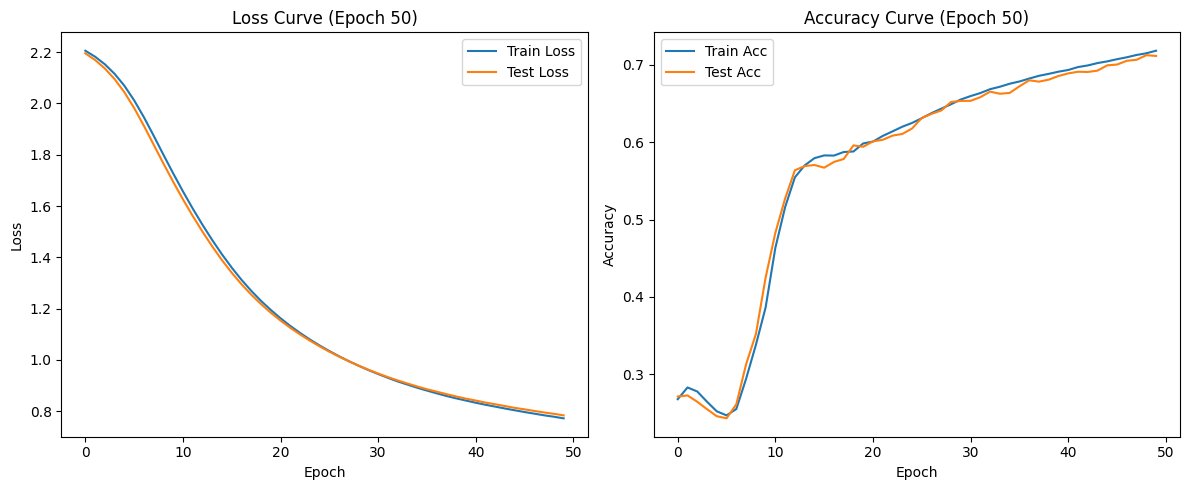

([2.205757922314583,
  2.1823902201145255,
  2.1528556965767067,
  2.115601265684087,
  2.069232870670075,
  2.0123969849119794,
  1.9465034429063188,
  1.8744402606436548,
  1.800204223774849,
  1.7274314662243457,
  1.6572632799757288,
  1.5902828652808008,
  1.5271050422749621,
  1.4674307402144087,
  1.411531305820384,
  1.3597931572731505,
  1.3123062838899329,
  1.2693417153459914,
  1.2300960804553742,
  1.1948815147927467,
  1.1623148177532439,
  1.132419285368412,
  1.1052081341439106,
  1.0797092110552686,
  1.0563157616777623,
  1.0345624842542283,
  1.0140636870201598,
  0.9950760569978268,
  0.9772732199506556,
  0.960506186840382,
  0.9449549682596896,
  0.9301469741983617,
  0.9160858458661019,
  0.9037790153888946,
  0.8914518982806104,
  0.8803698352042665,
  0.8697052666481505,
  0.8593108610903963,
  0.8500765250084248,
  0.841526691964332,
  0.832975102992768,
  0.8250573064418549,
  0.8178089978847097,
  0.810453101929198,
  0.8035165616806518,
  0.7967725190710514

In [39]:
trainer()